# Wavelength-Dependent Gordon Coefficients

This notebook demonstrates fitting wavelength-dependent Gordon coefficients (G1, G2) from Hydrolight radiative transfer simulations using the Loisel et al. (2023) dataset.

The Gordon semi-analytical model relates subsurface remote sensing reflectance to IOPs:

$$r_{rs}(\lambda) = G_1(\lambda) \cdot u(\lambda) + G_2(\lambda) \cdot u(\lambda)^2$$

where $u = b_b / (a + b_b)$ is the backscattering ratio.

Standard values are $G_1 = 0.0949$ and $G_2 = 0.0794$ (Gordon et al., 1988).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import calc_gordon

## Fit Gordon Coefficients at Selected Wavelengths

First, let's fit G1 and G2 at a few key wavelengths to compare with the standard values.

In [2]:
# Fit at selected wavelengths (matching fig_u analysis)
wave_select = np.array([370., 440., 500., 600.])

result_select, stats_select = calc_gordon.fit_gordon_from_loisel23(
    wave_select=wave_select,
    return_stats=True
)

# Print comparison table
calc_gordon.print_gordon_comparison(result_select)

Wavelength   G1 (fit)   G2 (fit)   G1 (std)   G2 (std)
----------------------------------------------------------
   370.0     0.0988     0.0564     0.0949     0.0794
   440.0     0.0945     0.0831     0.0949     0.0794
   500.0     0.0977     0.0316     0.0949     0.0794
   600.0     0.0993     -0.8895     0.0949     0.0794


In [3]:
# Print fitting statistics
print("Fitting statistics (rRMS * 100):")
for ii, wv in enumerate(result_select['wavelength']):
    print(f"  {wv:.0f} nm: {100*stats_select['rRMS'][ii]:.4f}")

Fitting statistics (rRMS * 100):
  370 nm: 2.2613
  440 nm: 2.7116
  500 nm: 3.5604
  600 nm: 3.4874


Loaded Loisel23 dataset with 81 wavelengths and 3320 spectra


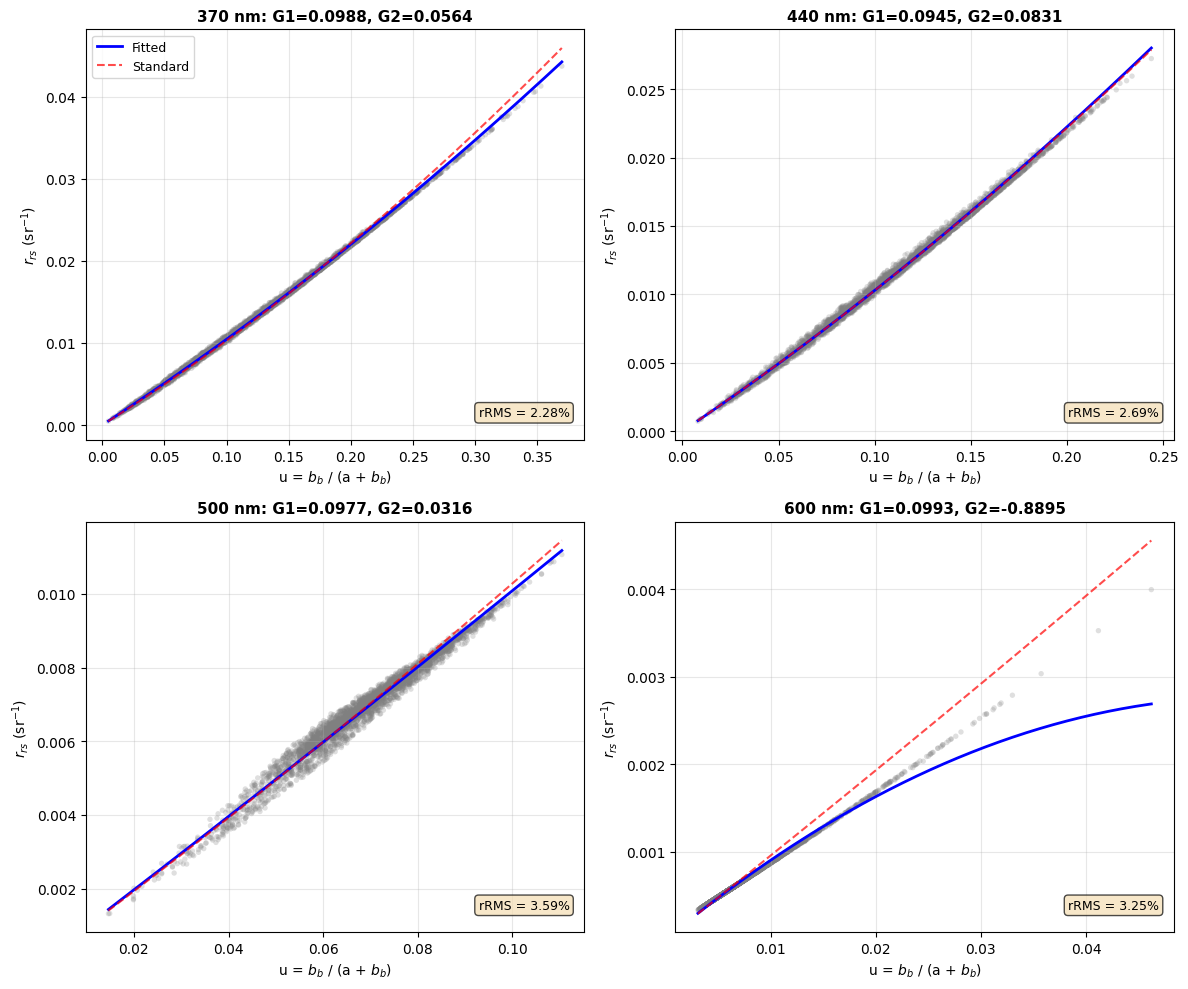

In [4]:
# Load the full Loisel23 dataset to get all spectra
from ocpy.hydrolight import loisel23

ds = loisel23.load_ds(1, 0)  # Elastic scattering

# Extract data
wave_l23 = ds.Lambda.data
Rrs_l23 = ds.Rrs.data
a_l23 = ds.a.data
bb_l23 = ds.bb.data

print(f"Loaded Loisel23 dataset with {len(wave_l23)} wavelengths and {a_l23.shape[0]} spectra")

# Create multi-panel plot for all selected wavelengths
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ii, wv_plot in enumerate(wave_select):
    ax = axes[ii]
    
    # Find closest wavelength in dataset
    idx_wv = np.argmin(np.abs(wave_l23 - wv_plot))
    actual_wv = wave_l23[idx_wv]
    
    # Calculate u and rrs at this wavelength
    u_data = calc_gordon.calc_u(a_l23[:, idx_wv], bb_l23[:, idx_wv])
    rrs_data = calc_gordon.Rrs_to_rrs(Rrs_l23[:, idx_wv])
    
    # Get fitted coefficients
    idx_fit = np.argmin(np.abs(result_select['wavelength'] - wv_plot))
    G1_fit = result_select['G1'][idx_fit]
    G2_fit = result_select['G2'][idx_fit]
    
    # Create model curves
    u_model = np.linspace(u_data.min(), u_data.max(), 200)
    rrs_fit = calc_gordon.rrs_model(u_model, G1_fit, G2_fit)
    rrs_standard = calc_gordon.rrs_model(u_model, calc_gordon.G1_STANDARD, calc_gordon.G2_STANDARD)
    
    # Plot
    ax.scatter(u_data, rrs_data, alpha=0.25, s=15, c='gray', edgecolors='none')
    ax.plot(u_model, rrs_fit, 'b-', lw=2, label='Fitted')
    ax.plot(u_model, rrs_standard, 'r--', lw=1.5, label='Standard', alpha=0.7)
    
    # Labels and formatting
    ax.set_xlabel('u = $b_b$ / (a + $b_b$)', fontsize=10)
    ax.set_ylabel('$r_{rs}$ (sr$^{-1}$)', fontsize=10)
    ax.set_title(f'{actual_wv:.0f} nm: G1={G1_fit:.4f}, G2={G2_fit:.4f}', 
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add legend only to first panel
    if ii == 0:
        ax.legend(loc='upper left', fontsize=9)
    
    # Calculate and display RMS
    residuals_fit = rrs_data - calc_gordon.rrs_model(u_data, G1_fit, G2_fit)
    rms_fit = np.sqrt(np.mean(residuals_fit**2))
    rrms_fit = 100 * np.sqrt(np.mean((residuals_fit / rrs_data)**2))
    
    # Add text box with RMS
    textstr = f'rRMS = {rrms_fit:.2f}%'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    ax.text(0.97, 0.05, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()

### Detailed View at 370 nm

Now zoom in on a single wavelength (370 nm) to see the data distribution and model fit more clearly.

Plotting detailed view at 370 nm
Fitted G1 = 0.0988, G2 = 0.0564
Standard G1 = 0.0949, G2 = 0.0794


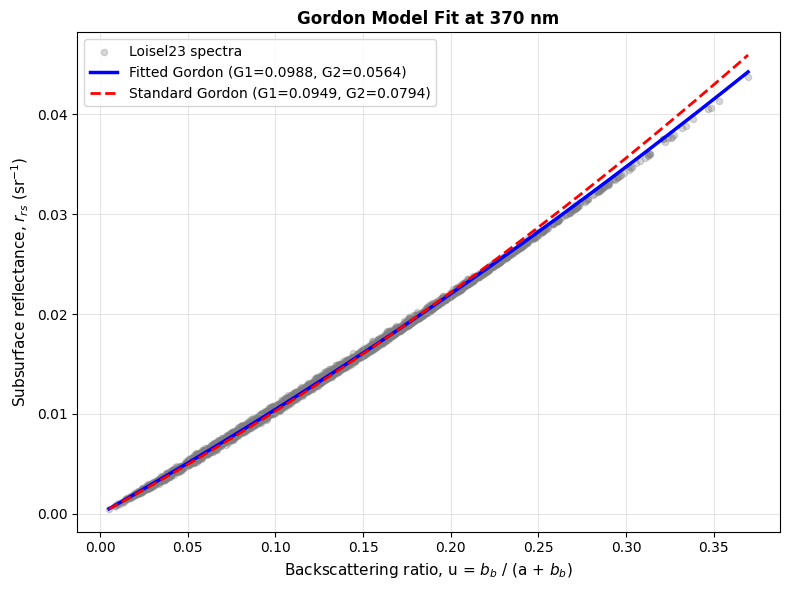


RMS residuals:
  Fitted model: 0.000208 sr^-1
  Standard model: 0.000354 sr^-1
  Improvement: 41.4%


In [5]:
# Select wavelength to visualize (370 nm)
wv_plot = 370.
idx_wv = np.argmin(np.abs(wave_l23 - wv_plot))
actual_wv = wave_l23[idx_wv]

print(f"Plotting detailed view at {actual_wv:.0f} nm")

# Calculate u and rrs at this wavelength for all spectra
u_data = calc_gordon.calc_u(a_l23[:, idx_wv], bb_l23[:, idx_wv])
rrs_data = calc_gordon.Rrs_to_rrs(Rrs_l23[:, idx_wv])

# Get fitted coefficients at this wavelength
idx_fit = np.argmin(np.abs(result_select['wavelength'] - wv_plot))
G1_fit = result_select['G1'][idx_fit]
G2_fit = result_select['G2'][idx_fit]

print(f"Fitted G1 = {G1_fit:.4f}, G2 = {G2_fit:.4f}")
print(f"Standard G1 = {calc_gordon.G1_STANDARD:.4f}, G2 = {calc_gordon.G2_STANDARD:.4f}")

# Create model curves for plotting
u_model = np.linspace(u_data.min(), u_data.max(), 200)
rrs_fit = calc_gordon.rrs_model(u_model, G1_fit, G2_fit)
rrs_standard = calc_gordon.rrs_model(u_model, calc_gordon.G1_STANDARD, calc_gordon.G2_STANDARD)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Data points
ax.scatter(u_data, rrs_data, alpha=0.3, s=20, c='gray', label='Loisel23 spectra')

# Fitted model
ax.plot(u_model, rrs_fit, 'b-', lw=2.5, 
        label=f'Fitted Gordon (G1={G1_fit:.4f}, G2={G2_fit:.4f})')

# Standard model
ax.plot(u_model, rrs_standard, 'r--', lw=2, 
        label=f'Standard Gordon (G1={calc_gordon.G1_STANDARD:.4f}, G2={calc_gordon.G2_STANDARD:.4f})')

ax.set_xlabel('Backscattering ratio, u = $b_b$ / (a + $b_b$)', fontsize=11)
ax.set_ylabel('Subsurface reflectance, $r_{rs}$ (sr$^{-1}$)', fontsize=11)
ax.set_title(f'Gordon Model Fit at {actual_wv:.0f} nm', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
residuals_fit = rrs_data - calc_gordon.rrs_model(u_data, G1_fit, G2_fit)
residuals_std = rrs_data - calc_gordon.rrs_model(u_data, calc_gordon.G1_STANDARD, calc_gordon.G2_STANDARD)

rms_fit = np.sqrt(np.mean(residuals_fit**2))
rms_std = np.sqrt(np.mean(residuals_std**2))

print(f"\nRMS residuals:")
print(f"  Fitted model: {rms_fit:.6f} sr^-1")
print(f"  Standard model: {rms_std:.6f} sr^-1")
print(f"  Improvement: {(1 - rms_fit/rms_std)*100:.1f}%")

## Visualize Gordon Model: rrs vs u Relationship

Examine how well the Gordon model $r_{rs} = G_1 \cdot u + G_2 \cdot u^2$ fits the Loisel23 Hydrolight simulations.

We'll compare:
- Scattered data points from all Loisel23 spectra
- Fitted Gordon coefficients (wavelength-specific)
- Standard Gordon coefficients (G1=0.0949, G2=0.0794)

### Multi-wavelength Comparison

First, visualize the fit quality at all selected wavelengths in a 2x2 panel.

## Fit Gordon Coefficients at All Wavelengths

Now fit G1 and G2 across the full visible spectrum.

In [6]:
# Fit all wavelengths in the 350-700 nm range
result_full, stats_full = calc_gordon.fit_gordon_from_loisel23(
    wv_min=350.,
    wv_max=750.,
    return_stats=True
)

print(f"Fitted {len(result_full['wavelength'])} wavelengths")
print(f"Wavelength range: {result_full['wavelength'].min():.0f} - {result_full['wavelength'].max():.0f} nm")

Fitted 81 wavelengths
Wavelength range: 350 - 750 nm


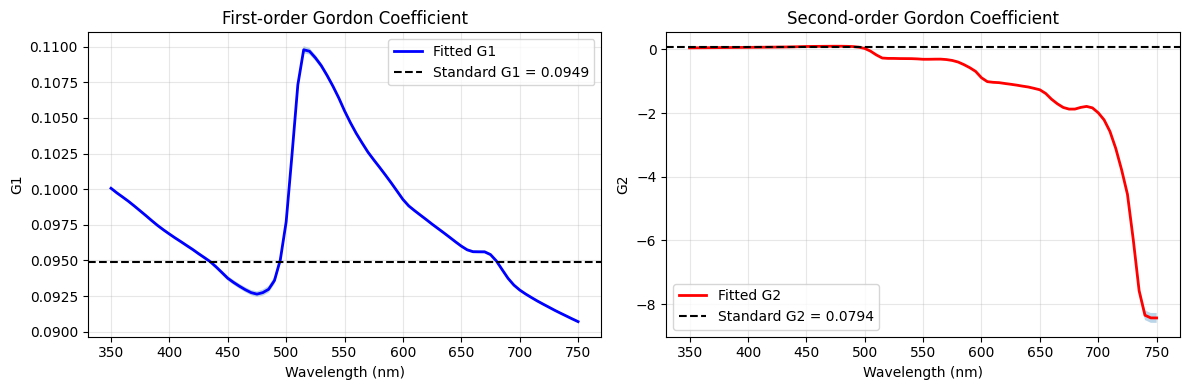

In [7]:
# Plot G1 and G2 vs wavelength
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# G1
ax = axes[0]
ax.plot(result_full['wavelength'], result_full['G1'], 'b-', lw=2, label='Fitted G1')
ax.fill_between(result_full['wavelength'], 
                result_full['G1'] - result_full['G1_err'],
                result_full['G1'] + result_full['G1_err'],
                alpha=0.3)
ax.axhline(calc_gordon.G1_STANDARD, color='k', ls='--', label=f'Standard G1 = {calc_gordon.G1_STANDARD}')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('G1')
ax.legend()
ax.set_title('First-order Gordon Coefficient')
ax.grid(True, alpha=0.3)

# G2
ax = axes[1]
ax.plot(result_full['wavelength'], result_full['G2'], 'r-', lw=2, label='Fitted G2')
ax.fill_between(result_full['wavelength'], 
                result_full['G2'] - result_full['G2_err'],
                result_full['G2'] + result_full['G2_err'],
                alpha=0.3)
ax.axhline(calc_gordon.G2_STANDARD, color='k', ls='--', label=f'Standard G2 = {calc_gordon.G2_STANDARD}')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('G2')
ax.legend()
ax.set_title('Second-order Gordon Coefficient')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

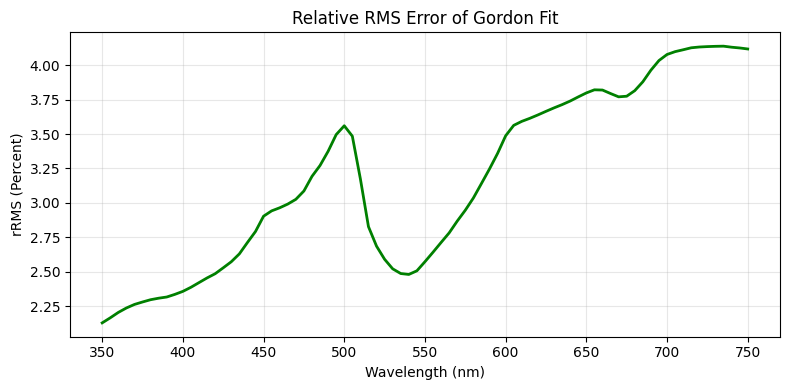

In [8]:
# Plot fitting quality (rRMS)
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(result_full['wavelength'], 100 * stats_full['rRMS'], 'g-', lw=2)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('rRMS (Percent)')
ax.set_title('Relative RMS Error of Gordon Fit')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Results at Key Ocean Color Wavelengths

In [9]:
# Standard ocean color wavelengths
key_wavelengths = np.array([412., 443., 490., 510., 555., 670.])

print("Gordon coefficients at standard ocean color wavelengths:")
print()
calc_gordon.print_gordon_comparison(result_full, key_wavelengths)

Gordon coefficients at standard ocean color wavelengths:

Wavelength   G1 (fit)   G2 (fit)   G1 (std)   G2 (std)
----------------------------------------------------------
   410.0     0.0963     0.0689     0.0949     0.0794
   445.0     0.0941     0.0874     0.0949     0.0794
   490.0     0.0936     0.0903     0.0949     0.0794
   510.0     0.1073     -0.1730     0.0949     0.0794
   555.0     0.1047     -0.3083     0.0949     0.0794
   670.0     0.0956     -1.8217     0.0949     0.0794


## Save Best G1 and G2 Values to Disk

Save the fitted wavelength-dependent Gordon coefficients for use in other analyses.

In [10]:
# Output file path
output_file = Path('gordon_coefficients.csv')

# Prepare data for CSV
import pandas as pd

# Create DataFrame with results
df = pd.DataFrame({
    'wavelength': result_full['wavelength'],
    'G1': result_full['G1'],
    'G2': result_full['G2'],
    'G1_err': result_full['G1_err'],
    'G2_err': result_full['G2_err'],
    'rRMS': stats_full['rRMS'],
    'RMS': stats_full['RMS']
})

'''
# Write to CSV with metadata as header comments
with open(output_file, 'w') as f:
    f.write(f"# Gordon coefficients fitted from Loisel23 Hydrolight simulations\n")
    f.write(f"# Source: Loisel et al. (2023) synthetic dataset\n")
    f.write(f"# Standard G1: {calc_gordon.G1_STANDARD}\n")
    f.write(f"# Standard G2: {calc_gordon.G2_STANDARD}\n")
    f.write("#\n")
    # Write the DataFrame to CSV
    df.to_csv(f, index=False)

print(f"Saved Gordon coefficients to: {output_file.absolute()}")
'''

'\n# Write to CSV with metadata as header comments\nwith open(output_file, \'w\') as f:\n    f.write(f"# Gordon coefficients fitted from Loisel23 Hydrolight simulations\n")\n    f.write(f"# Source: Loisel et al. (2023) synthetic dataset\n")\n    f.write(f"# Standard G1: {calc_gordon.G1_STANDARD}\n")\n    f.write(f"# Standard G2: {calc_gordon.G2_STANDARD}\n")\n    f.write("#\n")\n    # Write the DataFrame to CSV\n    df.to_csv(f, index=False)\n\nprint(f"Saved Gordon coefficients to: {output_file.absolute()}")\n'

In [11]:
# Verify the saved file
df_loaded = pd.read_csv(output_file, comment='#')
print("Contents of saved CSV file:")
print(f"  Shape: {df_loaded.shape}")
print(f"  Columns: {list(df_loaded.columns)}")
print(f"\nFirst few rows:")
print(df_loaded.head())

Contents of saved CSV file:
  Shape: (81, 7)
  Columns: ['wavelength', 'G1', 'G2', 'G1_err', 'G2_err', 'rRMS', 'RMS']

First few rows:
   wavelength        G1        G2  G1_err  G2_err      rRMS       RMS
0       350.0  0.100073  0.050540     0.0     0.0  0.021271  0.000189
1       355.0  0.099756  0.052029     0.0     0.0  0.021633  0.000194
2       360.0  0.099440  0.053529     0.0     0.0  0.022037  0.000199
3       365.0  0.099121  0.055026     0.0     0.0  0.022366  0.000204
4       370.0  0.098799  0.056505     0.0     0.0  0.022622  0.000208


## Example: Using the Saved Coefficients

Demonstrate loading and using the saved coefficients to calculate Rrs.

In [12]:
# Load saved coefficients
df = pd.read_csv(output_file, comment='#')
wave = df['wavelength'].values
G1 = df['G1'].values
G2 = df['G2'].values

# Create synthetic IOPs for demonstration
# Simple exponential absorption + power-law backscattering
a = 0.02 * np.exp(-0.014 * (wave - 440))  # absorption
bb = 0.005 * (440 / wave)**1.0  # backscattering

# Add water contributions (simplified)
a_w = 0.0145 * np.exp(0.014 * (wave - 440))  # rough approximation
bb_w = 0.0015 * (500 / wave)**4.3  # Rayleigh-like

a_total = a + a_w
bb_total = bb + bb_w

# Calculate Rrs with standard vs wavelength-dependent Gordon coefficients
from bing.rt import calc_Rrs

Rrs_standard = calc_Rrs(a_total, bb_total)  # uses G1=0.0949, G2=0.0794
Rrs_variable = calc_gordon.calc_Rrs_with_variable_gordon(a_total, bb_total, G1, G2)

# Plot comparison
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(wave, Rrs_standard, 'b-', lw=2, label='Standard Gordon coefficients')
ax.plot(wave, Rrs_variable, 'r--', lw=2, label='Wavelength-dependent coefficients')

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Rrs (sr$^{-1}$)')
ax.set_title('Effect of Wavelength-Dependent Gordon Coefficients')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print relative difference
rel_diff = 100 * (Rrs_variable - Rrs_standard) / Rrs_standard
print(f"Relative difference range: {rel_diff.min():.1f}% to {rel_diff.max():.1f}%")

Relative difference range: -22.3% to 1.2%


/tmp/ipykernel_857702/3160227474.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Summary

The wavelength-dependent Gordon coefficients derived from Loisel23 Hydrolight simulations show:

1. **G1** increases slightly with wavelength (0.10-0.14 vs standard 0.0949)
2. **G2** decreases and becomes negative at longer wavelengths, indicating the quadratic term may not be appropriate in all optical regimes
3. Best agreement with standard values occurs in the blue (400-490 nm) where most ocean color algorithms operate

The saved `gordon_coefficients.csv` file can be loaded and used in BING or other radiative transfer calculations.